In [13]:
# =========================================================
# IMPORT LIBRARIES + LOAD DONOR CONCENTRATION SHEET
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [14]:
# =========================================================
# LOAD DONOR CONCENTRATION SHEET
# =========================================================

file_path = "Data_file.xlsx"
sheet_name = "Donor Con"

# Load dataset
df = pd.read_excel(file_path, sheet_name=sheet_name)

# Display basic info
print("Donor Concentration Sheet Loaded Successfully!")
print("Shape of Dataset:", df.shape)

# Show column names
print("\nColumns in Donor Concentration Sheet:")
print(df.columns.tolist())

# Preview first rows
df.head()

Donor Concentration Sheet Loaded Successfully!
Shape of Dataset: (61, 32)

Columns in Donor Concentration Sheet:
['Jsc', 'v(V)', '10^13', '10^14', '10^15', '10^16', '10^17', '10^18', 'Unnamed: 8', 'Unnamed: 9', 'Donor con', 'Jsc(mA/cm^2', 'Unnamed: 12', 'Unnamed: 13', 'Q.E.(%)', 'lambda(nm)', '10^13.1', '10^14.1', '10^15.1', '10^16.1', '10^17.1', '10^18.1', 'Unnamed: 22', 'Unnamed: 23', 'R(A/W)', 'lambda(nm).1', '10^13.2', '10^14.2', '10^15.2', '10^16.2', '10^17.2', '10^18.2']


,Jsc,v(V),10^13,10^14,10^15,10^16,10^17,10^18,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,R(A/W),lambda(nm).1,10^13.2,10^14.2,10^15.2,10^16.2,10^17.2,10^18.2
0,NaN,0.00,23.595521,23.596469,23.327481,12.865889,5.240605,5.052401,NaN,NaN,...,NaN,NaN,NaN,300,0.203713,0.203713,0.199886,0.137546,0.047114,0.007126
1,NaN,0.05,23.595373,23.596327,23.300797,12.837731,5.187701,5.051149,NaN,NaN,...,NaN,NaN,NaN,310,0.212986,0.212987,0.209088,0.144390,0.049737,0.007565
2,NaN,0.10,23.595221,23.596181,23.273073,12.809530,5.145931,5.049878,NaN,NaN,...,NaN,NaN,NaN,320,0.222504,0.222504,0.218547,0.151497,0.052493,0.008032
3,NaN,0.15,23.595063,23.596031,23.244281,12.780941,5.112207,5.048583,NaN,NaN,...,NaN,NaN,NaN,330,0.232309,0.232310,0.228308,0.158913,0.055404,0.008535
4,NaN,0.20,23.594897,23.595875,23.214395,12.751937,5.084248,5.047262,NaN,NaN,...,NaN,NaN,NaN,340,0.242465,0.242466,0.238434,0.166698,0.058507,0.009080


In [15]:
# =========================================================
# EXTRACT J-V DATA (DONOR CONCENTRATION)
# =========================================================

# Select voltage + J-V columns only
jv_cols = ['v(V)'] + [
    col for col in df.columns
    if str(col).startswith('10^') and '.1' not in str(col) and '.2' not in str(col)
]

# Create J-V dataframe
jv_df = df[jv_cols]

# Convert wide to long format
jv_long = jv_df.melt(
    id_vars='v(V)',
    var_name='Donor_Concentration',
    value_name='Current'
)

# Extract exponent only (10^13 → 13)
jv_long['Donor_Concentration'] = jv_long['Donor_Concentration'].str.extract(r'10\^(\d+)').astype(float)

# Remove NaN values
jv_long.dropna(inplace=True)

# Rename columns
jv_long.rename(columns={'v(V)': 'Voltage'}, inplace=True)

# Reset index
jv_long.reset_index(drop=True, inplace=True)

print("J-V Donor Concentration Data Ready!")
print("Shape:", jv_long.shape)

jv_long.head()

J-V Donor Concentration Data Ready!
Shape: (147, 3)


,Voltage,Donor_Concentration,Current
0,0.00,13.0,23.595521
1,0.05,13.0,23.595373
2,0.10,13.0,23.595221
3,0.15,13.0,23.595063
4,0.20,13.0,23.594897


In [16]:
# =========================================================
# EXTRACT QE DATA (DONOR CONCENTRATION)
# =========================================================

# Select wavelength + QE columns only
qe_cols = ['lambda(nm)'] + [
    col for col in df.columns
    if str(col).startswith('10^') and '.1' in str(col)
]

# Create QE dataframe
qe_df = df[qe_cols]

# Convert wide to long format
qe_long = qe_df.melt(
    id_vars='lambda(nm)',
    var_name='Donor_Concentration',
    value_name='QE'
)

# Extract exponent only (10^13.1 → 13)
qe_long['Donor_Concentration'] = qe_long['Donor_Concentration'].str.extract(r'10\^(\d+)').astype(float)

# Remove NaN values
qe_long.dropna(inplace=True)

# Rename columns
qe_long.rename(columns={'lambda(nm)': 'Wavelength'}, inplace=True)

# Reset index
qe_long.reset_index(drop=True, inplace=True)

print("QE Donor Concentration Data Ready!")
print("Shape:", qe_long.shape)

qe_long.head()

QE Donor Concentration Data Ready!
Shape: (366, 3)


,Wavelength,Donor_Concentration,QE
0,300,13.0,84.20140
1,310,13.0,85.19456
2,320,13.0,86.22028
3,330,13.0,87.29192
4,340,13.0,88.42853


In [17]:
# =========================================================
# EXTRACT RESPONSIVITY DATA (DONOR CONCENTRATION)
# =========================================================

# Select wavelength + Responsivity columns only
r_cols = ['lambda(nm).1'] + [
    col for col in df.columns
    if str(col).startswith('10^') and '.2' in str(col)
]

# Create Responsivity dataframe
r_df = df[r_cols]

# Convert wide to long format
r_long = r_df.melt(
    id_vars='lambda(nm).1',
    var_name='Donor_Concentration',
    value_name='Responsivity'
)

# Extract exponent only (10^13.2 → 13)
r_long['Donor_Concentration'] = r_long['Donor_Concentration'].str.extract(r'10\^(\d+)').astype(float)

# Remove NaN values
r_long.dropna(inplace=True)

# Rename columns
r_long.rename(columns={'lambda(nm).1': 'Wavelength'}, inplace=True)

# Reset index
r_long.reset_index(drop=True, inplace=True)

print("Responsivity Donor Concentration Data Ready!")
print("Shape:", r_long.shape)

r_long.head()

Responsivity Donor Concentration Data Ready!
Shape: (366, 3)


,Wavelength,Donor_Concentration,Responsivity
0,300,13.0,0.203713
1,310,13.0,0.212986
2,320,13.0,0.222504
3,330,13.0,0.232309
4,340,13.0,0.242465


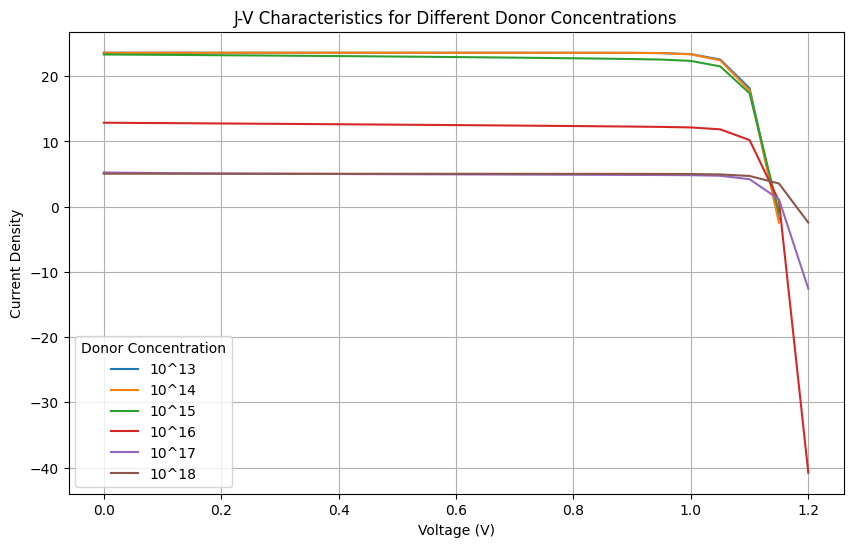

In [18]:
# =========================================================
# PLOT J-V CURVES (DONOR CONCENTRATION)
# =========================================================

plt.figure(figsize=(10,6))

for donor in sorted(jv_long['Donor_Concentration'].unique()):
    subset = jv_long[jv_long['Donor_Concentration'] == donor]

    plt.plot(
        subset['Voltage'],
        subset['Current'],
        label=f'10^{int(donor)}'
    )

plt.title("J-V Characteristics for Different Donor Concentrations")
plt.xlabel("Voltage (V)")
plt.ylabel("Current Density")

plt.legend(title="Donor Concentration")
plt.grid(True)
plt.show()

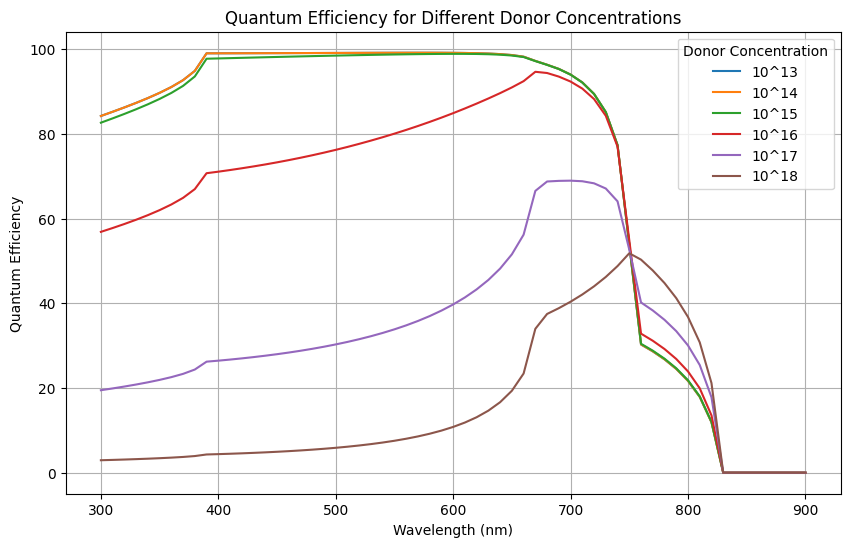

In [19]:
# =========================================================
# PLOT QE CURVES (DONOR CONCENTRATION)
# =========================================================

plt.figure(figsize=(10,6))

for donor in sorted(qe_long['Donor_Concentration'].unique()):
    subset = qe_long[qe_long['Donor_Concentration'] == donor]

    plt.plot(
        subset['Wavelength'],
        subset['QE'],
        label=f'10^{int(donor)}'
    )

plt.title("Quantum Efficiency for Different Donor Concentrations")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Quantum Efficiency")

plt.legend(title="Donor Concentration")
plt.grid(True)
plt.show()

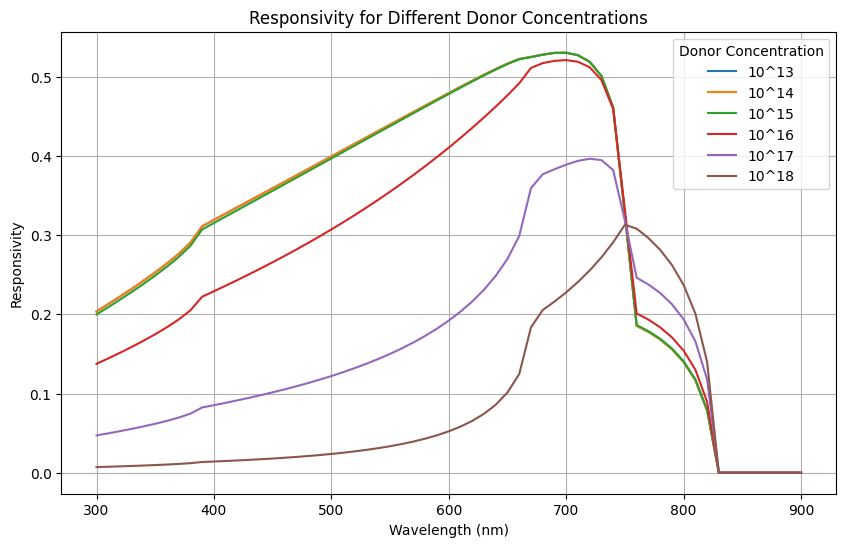

In [20]:
# =========================================================
# PLOT RESPONSIVITY CURVES (DONOR CONCENTRATION)
# =========================================================

plt.figure(figsize=(10,6))

for donor in sorted(r_long['Donor_Concentration'].unique()):
    subset = r_long[r_long['Donor_Concentration'] == donor]

    plt.plot(
        subset['Wavelength'],
        subset['Responsivity'],
        label=f'10^{int(donor)}'
    )

plt.title("Responsivity for Different Donor Concentrations")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Responsivity")

plt.legend(title="Donor Concentration")
plt.grid(True)
plt.show()

J-V Donor Concentration Model Performance
R² Score: 0.6413551107220872
MAE: 1.5525761117099994


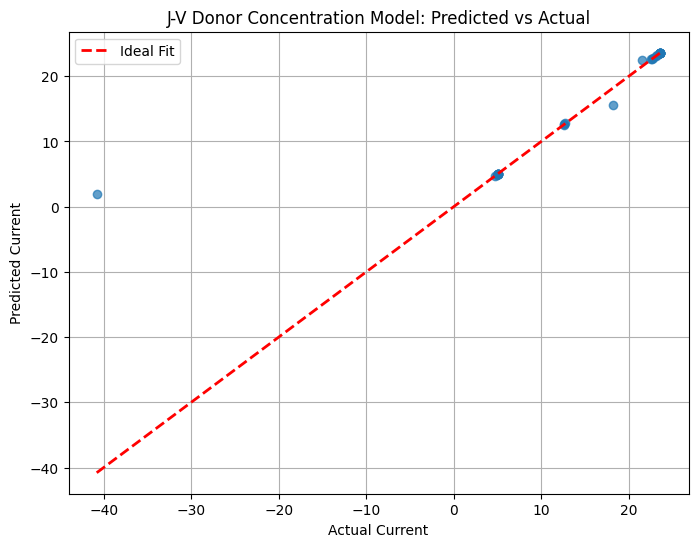

In [21]:
# =========================================================
# J-V MACHINE LEARNING MODEL (DONOR CONCENTRATION)
# =========================================================

# Features and target
X_jv = jv_long[['Voltage', 'Donor_Concentration']]
y_jv = jv_long['Current']

# Train-test split
X_train_jv, X_test_jv, y_train_jv, y_test_jv = train_test_split(
    X_jv, y_jv,
    test_size=0.2,
    random_state=42
)

# Model
jv_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
jv_model.fit(X_train_jv, y_train_jv)

# Predict
y_pred_jv = jv_model.predict(X_test_jv)

# Metrics
print("J-V Donor Concentration Model Performance")
print("R² Score:", r2_score(y_test_jv, y_pred_jv))
print("MAE:", mean_absolute_error(y_test_jv, y_pred_jv))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_jv, y_pred_jv, alpha=0.7)

# Ideal reference line
min_val = min(y_test_jv.min(), y_pred_jv.min())
max_val = max(y_test_jv.max(), y_pred_jv.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual Current")
plt.ylabel("Predicted Current")
plt.title("J-V Donor Concentration Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

QE Donor Concentration Model Performance
R² Score: 0.9990498368152401
MAE: 0.6270434003925496


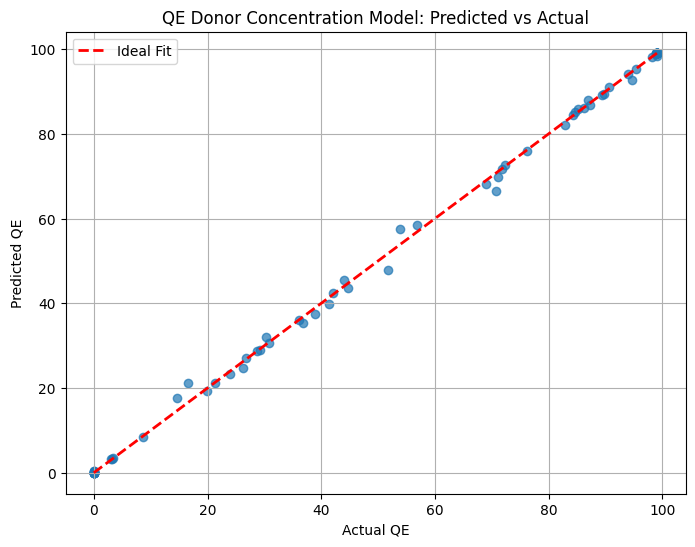

In [22]:
# =========================================================
# QE MACHINE LEARNING MODEL (DONOR CONCENTRATION)
# =========================================================

# Features and target
X_qe = qe_long[['Wavelength', 'Donor_Concentration']]
y_qe = qe_long['QE']

# Train-test split
X_train_qe, X_test_qe, y_train_qe, y_test_qe = train_test_split(
    X_qe, y_qe,
    test_size=0.2,
    random_state=42
)

# Model
qe_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
qe_model.fit(X_train_qe, y_train_qe)

# Predict
y_pred_qe = qe_model.predict(X_test_qe)

# Metrics
print("QE Donor Concentration Model Performance")
print("R² Score:", r2_score(y_test_qe, y_pred_qe))
print("MAE:", mean_absolute_error(y_test_qe, y_pred_qe))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_qe, y_pred_qe, alpha=0.7)

# Ideal reference line
min_val = min(y_test_qe.min(), y_pred_qe.min())
max_val = max(y_test_qe.max(), y_pred_qe.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual QE")
plt.ylabel("Predicted QE")
plt.title("QE Donor Concentration Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

Responsivity Donor Concentration Model Performance
R² Score: 0.9976371697107401
MAE: 0.0050801801756002055


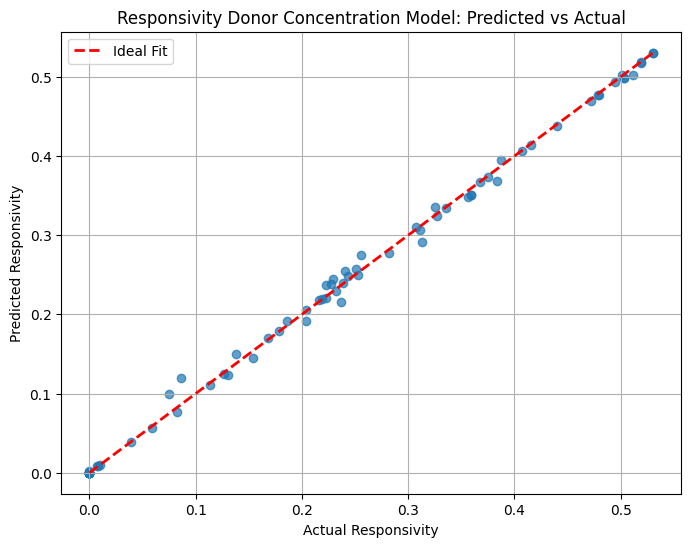

In [23]:
# =========================================================
# RESPONSIVITY MACHINE LEARNING MODEL (DONOR CONCENTRATION)
# =========================================================

# Features and target
X_r = r_long[['Wavelength', 'Donor_Concentration']]
y_r = r_long['Responsivity']

# Train-test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r,
    test_size=0.2,
    random_state=42
)

# Model
r_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train
r_model.fit(X_train_r, y_train_r)

# Predict
y_pred_r = r_model.predict(X_test_r)

# Metrics
print("Responsivity Donor Concentration Model Performance")
print("R² Score:", r2_score(y_test_r, y_pred_r))
print("MAE:", mean_absolute_error(y_test_r, y_pred_r))

# Plot Predicted vs Actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_r, y_pred_r, alpha=0.7)

# Ideal reference line
min_val = min(y_test_r.min(), y_pred_r.min())
max_val = max(y_test_r.max(), y_pred_r.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label="Ideal Fit"
)

plt.xlabel("Actual Responsivity")
plt.ylabel("Predicted Responsivity")
plt.title("Responsivity Donor Concentration Model: Predicted vs Actual")

plt.legend()
plt.grid(True)
plt.show()

In [24]:
# =========================================================
# PREDICT CURRENT (DONOR CONCENTRATION)
# =========================================================

def predict_current(voltage, donor_concentration):

    prediction = jv_model.predict([[voltage, donor_concentration]])[0]

    print(f"Predicted Current Density at {voltage} V and 10^{int(donor_concentration)} Donor Concentration: {prediction}")

    return prediction

In [25]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

voltage = float(input("Enter Voltage (V): "))
donor_concentration = float(input("Enter Donor Concentration Exponent (Example: 13 for 10^13): "))

predict_current(voltage, donor_concentration)

Predicted Current Density at 1000.0 V and 10^13 Donor Concentration: -1.0057963913899974


c:\Users\yashv\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(-1.0057963913899974)

In [26]:
# =========================================================
# PREDICT QE (DONOR CONCENTRATION)
# =========================================================

def predict_qe(wavelength, donor_concentration):

    prediction = qe_model.predict([[wavelength, donor_concentration]])[0]

    print(f"Predicted QE at {wavelength} nm and 10^{int(donor_concentration)} Donor Concentration: {prediction}")

    return prediction

In [27]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

wavelength = float(input("Enter Wavelength (nm): "))
donor_concentration = float(input("Enter Donor Concentration Exponent (Example: 13 for 10^13): "))

predict_qe(wavelength, donor_concentration)

Predicted QE at 500.0 nm and 10^15 Donor Concentration: 98.4422720499999


c:\Users\yashv\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(98.4422720499999)

In [28]:
# =========================================================
# PREDICT RESPONSIVITY (DONOR CONCENTRATION)
# =========================================================

def predict_responsivity(wavelength, donor_concentration):

    prediction = r_model.predict([[wavelength, donor_concentration]])[0]

    print(f"Predicted Responsivity at {wavelength} nm and 10^{int(donor_concentration)} Donor Concentration: {prediction}")

    return prediction

In [29]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

wavelength = float(input("Enter Wavelength (nm): "))
donor_concentration = float(input("Enter Donor Concentration Exponent (Example: 13 for 10^13): "))

predict_responsivity(wavelength, donor_concentration)

Predicted Responsivity at 600.0 nm and 10^17 Donor Concentration: 0.18804580073387114


c:\Users\yashv\anaconda3\envs\py312\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


np.float64(0.18804580073387114)

In [30]:
# =========================================================
# PREDICT FULL J-V CURVE (DONOR CONCENTRATION)
# =========================================================

def predict_jv_curve(donor_concentration):

    voltage_range = np.linspace(
        jv_long['Voltage'].min(),
        jv_long['Voltage'].max(),
        200
    )

    X_curve = pd.DataFrame({
        'Voltage': voltage_range,
        'Donor_Concentration': donor_concentration
    })

    predicted_current = jv_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        voltage_range,
        predicted_current,
        label=f'Predicted Donor Concentration = 10^{int(donor_concentration)}'
    )

    plt.title("Predicted J-V Curve")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current Density")

    plt.legend()
    plt.grid(True)
    plt.show()

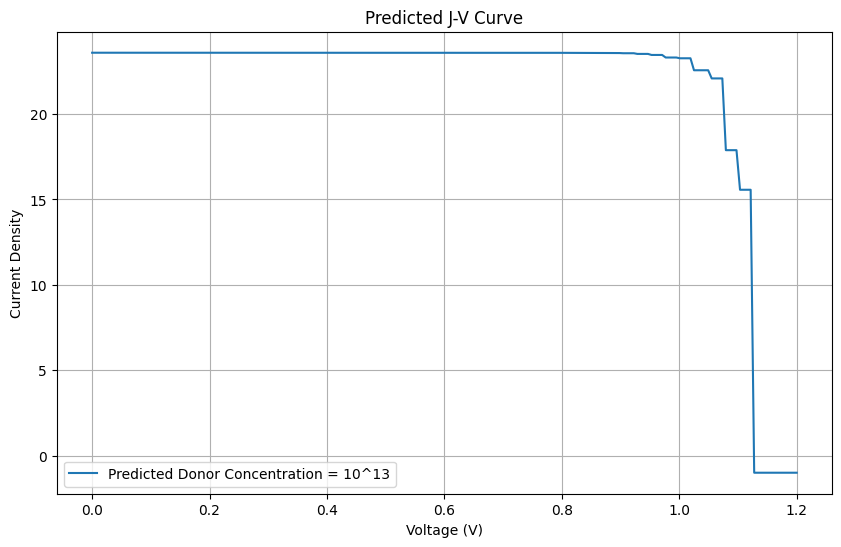

In [31]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

donor_concentration = float(input("Enter Donor Concentration Exponent (Example: 13 for 10^13): "))

predict_jv_curve(donor_concentration)

In [32]:
# =========================================================
# PREDICT FULL QE CURVE (DONOR CONCENTRATION)
# =========================================================

def predict_qe_curve(donor_concentration):

    wavelength_range = np.linspace(
        qe_long['Wavelength'].min(),
        qe_long['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Donor_Concentration': donor_concentration
    })

    predicted_qe = qe_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        wavelength_range,
        predicted_qe,
        label=f'Predicted Donor Concentration = 10^{int(donor_concentration)}'
    )

    plt.title("Predicted QE Curve")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Quantum Efficiency")

    plt.legend()
    plt.grid(True)
    plt.show()

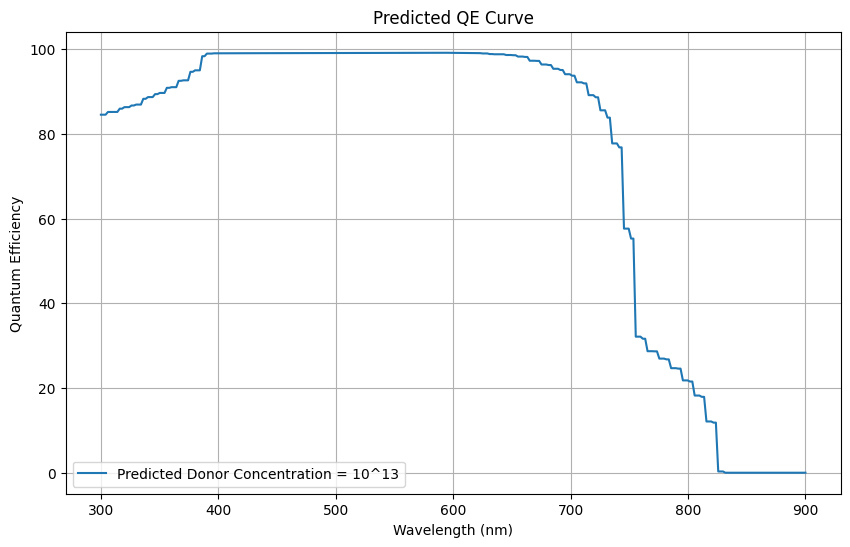

In [33]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

donor_concentration = float(input("Enter Donor Concentration Exponent (Example: 13 for 10^13): "))

predict_qe_curve(donor_concentration)

In [34]:
# =========================================================
# PREDICT FULL RESPONSIVITY CURVE (DONOR CONCENTRATION)
# =========================================================

def predict_r_curve(donor_concentration):

    wavelength_range = np.linspace(
        r_long['Wavelength'].min(),
        r_long['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Donor_Concentration': donor_concentration
    })

    predicted_r = r_model.predict(X_curve)

    plt.figure(figsize=(10,6))

    plt.plot(
        wavelength_range,
        predicted_r,
        label=f'Predicted Donor Concentration = 10^{int(donor_concentration)}'
    )

    plt.title("Predicted Responsivity Curve")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Responsivity")

    plt.legend()
    plt.grid(True)
    plt.show()

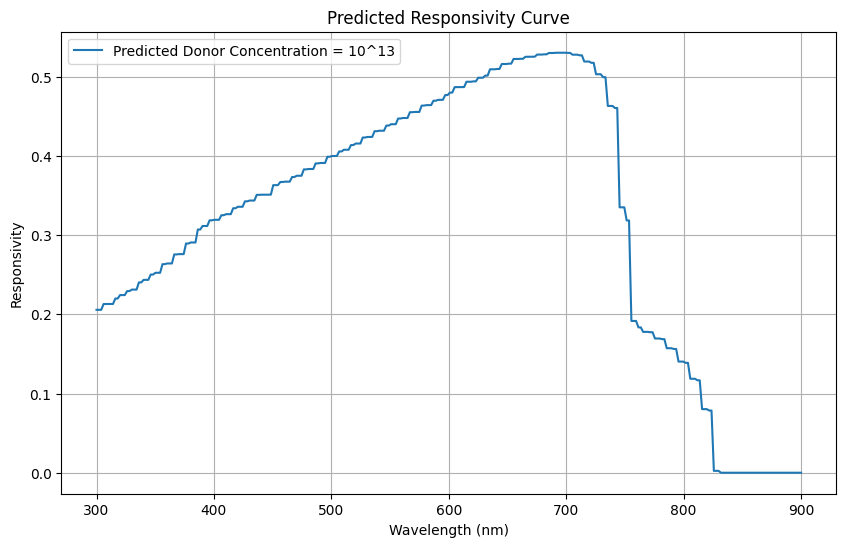

In [35]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

donor_concentration = float(input("Enter Donor Concentration Exponent (Example: 13 for 10^13): "))

predict_r_curve(donor_concentration)

In [36]:
# =========================================================
# ACTUAL vs PREDICTED J-V CURVE (DONOR CONCENTRATION)
# =========================================================

def compare_jv_actual_vs_predicted(donor_concentration):

    # Actual SCAPS data
    actual_data = jv_long[jv_long['Donor_Concentration'] == donor_concentration]

    if actual_data.empty:
        print("Donor Concentration not found in dataset.")
        return

    # Predicted curve
    voltage_range = np.linspace(
        actual_data['Voltage'].min(),
        actual_data['Voltage'].max(),
        200
    )

    X_curve = pd.DataFrame({
        'Voltage': voltage_range,
        'Donor_Concentration': donor_concentration
    })

    predicted_current = jv_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Voltage'],
        actual_data['Current'],
        label="Actual SCAPS"
    )

    plt.plot(
        voltage_range,
        predicted_current,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted J-V Curve (10^{int(donor_concentration)})")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current Density")

    plt.legend()
    plt.grid(True)
    plt.show()

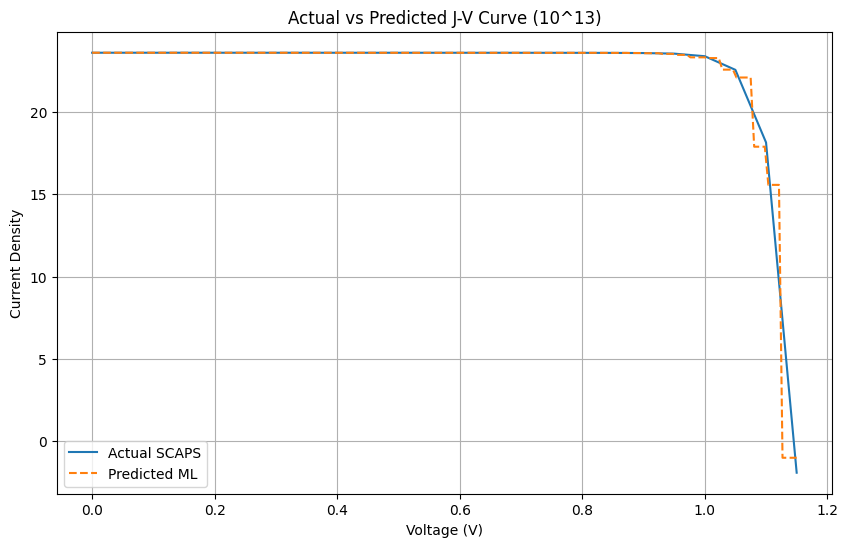

In [37]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

donor_concentration = float(input("Enter Existing Donor Concentration Exponent (Example: 13 for 10^13): "))

compare_jv_actual_vs_predicted(donor_concentration)

In [38]:
# =========================================================
# ACTUAL vs PREDICTED QE CURVE (DONOR CONCENTRATION)
# =========================================================

def compare_qe_actual_vs_predicted(donor_concentration):

    # Actual SCAPS data
    actual_data = qe_long[qe_long['Donor_Concentration'] == donor_concentration]

    if actual_data.empty:
        print("Donor Concentration not found in dataset.")
        return

    # Predicted curve
    wavelength_range = np.linspace(
        actual_data['Wavelength'].min(),
        actual_data['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Donor_Concentration': donor_concentration
    })

    predicted_qe = qe_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Wavelength'],
        actual_data['QE'],
        label="Actual SCAPS"
    )

    plt.plot(
        wavelength_range,
        predicted_qe,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted QE Curve (10^{int(donor_concentration)})")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Quantum Efficiency")

    plt.legend()
    plt.grid(True)
    plt.show()

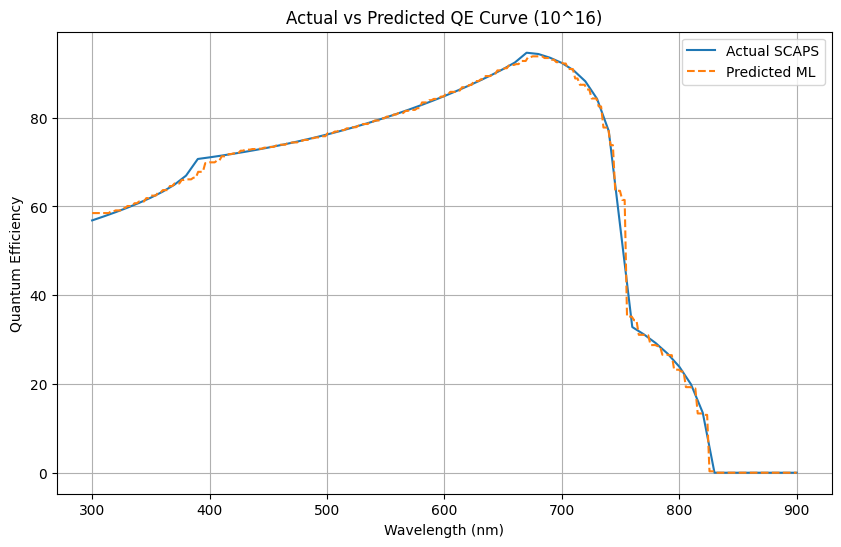

In [39]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

donor_concentration = float(input("Enter Existing Donor Concentration Exponent (Example: 13 for 10^13): "))

compare_qe_actual_vs_predicted(donor_concentration)

In [40]:
# =========================================================
# ACTUAL vs PREDICTED RESPONSIVITY CURVE (DONOR CONCENTRATION)
# =========================================================

def compare_r_actual_vs_predicted(donor_concentration):

    # Actual SCAPS data
    actual_data = r_long[r_long['Donor_Concentration'] == donor_concentration]

    if actual_data.empty:
        print("Donor Concentration not found in dataset.")
        return

    # Predicted curve
    wavelength_range = np.linspace(
        actual_data['Wavelength'].min(),
        actual_data['Wavelength'].max(),
        300
    )

    X_curve = pd.DataFrame({
        'Wavelength': wavelength_range,
        'Donor_Concentration': donor_concentration
    })

    predicted_r = r_model.predict(X_curve)

    # Plot
    plt.figure(figsize=(10,6))

    plt.plot(
        actual_data['Wavelength'],
        actual_data['Responsivity'],
        label="Actual SCAPS"
    )

    plt.plot(
        wavelength_range,
        predicted_r,
        '--',
        label="Predicted ML"
    )

    plt.title(f"Actual vs Predicted Responsivity Curve (10^{int(donor_concentration)})")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Responsivity")

    plt.legend()
    plt.grid(True)
    plt.show()

In [41]:
# =========================================================
# HOW TO USE (USER INPUT)
# =========================================================

donor_concentration = float(input("Enter Existing Donor Concentration Exponent (Example: 13 for 10^13): "))

compare_r_actual_vs_predicted(donor_concentration)

Donor Concentration not found in dataset.


In [42]:
# =========================================================
# DONOR CONCENTRATION THEORY + SYSTEM WORKING
# =========================================================

print("""
============================================================
DONOR CONCENTRATION VARIATION THEORY IN PEROVSKITE SOLAR CELLS
============================================================

In this project, Donor Concentration refers to the density of donor 
dopants introduced into a semiconductor layer, typically the Electron 
Transport Layer (ETL), to control charge carrier concentration.

Donor dopants increase the number of free electrons available for 
charge transport, thereby influencing conductivity and electron 
extraction efficiency.

Thus, donor concentration is an important electronic parameter that 
affects transport-layer performance and overall device behavior.

------------------------------------------------------------
WHY DONOR CONCENTRATION IS IMPORTANT
------------------------------------------------------------

Donor Concentration influences:
• Free electron density
• Electrical conductivity
• Carrier transport
• Built-in electric field
• Current density
• Voltage response

At lower donor concentration:
• Reduced carrier availability
• Lower conductivity
• Potentially weaker charge extraction

At higher donor concentration:
• Improved electron transport
• Enhanced conductivity
• Better extraction up to practical limits

However, excessive doping may also influence recombination or 
electrical balance.

Therefore, studying donor concentration helps evaluate how 
semiconductor doping affects photovoltaic performance.

------------------------------------------------------------
ROLE OF SCAPS DATASET
------------------------------------------------------------

The Excel dataset contains SCAPS-generated simulation data for 
multiple donor concentration values represented as:
10^13, 10^14, 10^15, 10^16, 10^17, 10^18

For each donor concentration, SCAPS provides:

1. J–V Data:
Voltage vs Current Density

2. QE Data:
Wavelength vs Quantum Efficiency

3. Responsivity Data:
Wavelength vs Responsivity

Each donor concentration therefore represents a different doping 
condition simulation.

------------------------------------------------------------
WHAT THIS ML SYSTEM DOES
------------------------------------------------------------

Instead of manually analyzing every donor concentration separately, 
Machine Learning learns doping-response behavior from SCAPS data.

Three Random Forest models are trained:

J–V Model:
(Voltage + Donor Concentration) → Current

QE Model:
(Wavelength + Donor Concentration) → QE

Responsivity Model:
(Wavelength + Donor Concentration) → Responsivity

For ML simplicity, concentrations are represented using exponent form:
10^13 → 13
10^18 → 18

This allows prediction of:
• Current at selected voltage and donor concentration
• QE at selected wavelength and donor concentration
• Responsivity at selected wavelength and donor concentration
• Full predicted curves for user-selected concentration

------------------------------------------------------------
MODEL VALIDATION
------------------------------------------------------------

To ensure reliability:
• R² Score evaluates predictive accuracy
• MAE measures average error
• Predicted vs Actual plots verify consistency

This confirms whether ML successfully captures donor-doping trends.

------------------------------------------------------------
ACTUAL vs PREDICTED COMPARISON
------------------------------------------------------------

For known donor concentration values:
• Actual SCAPS curves are plotted
• Predicted ML curves are plotted

This helps evaluate:
• Learning quality
• Doping-pattern understanding
• Predictive consistency

------------------------------------------------------------
SYSTEM SIGNIFICANCE
------------------------------------------------------------

This framework combines:
SCAPS Simulation + Doping Analysis + Machine Learning

Thus, it serves as:
• Doping-performance analysis tool
• Predictive modeling framework
• Visualization system

Rather than replacing SCAPS, this system extends donor-doping 
analysis by enabling:
• Faster predictions
• Easier concentration exploration
• Reusable analysis framework

============================================================
FINAL SUMMARY
============================================================

Donor Concentration represents semiconductor doping level.
It strongly affects conductivity and carrier transport.
SCAPS provides donor-concentration-based simulation data.
Machine Learning learns doping-response behavior.
The final system predicts and visualizes donor concentration effects.

In short:
This project creates a reusable donor-doping simulation and 
prediction framework for perovskite solar-cell analysis.
============================================================
""")


DONOR CONCENTRATION VARIATION THEORY IN PEROVSKITE SOLAR CELLS

In this project, Donor Concentration refers to the density of donor 
dopants introduced into a semiconductor layer, typically the Electron 
Transport Layer (ETL), to control charge carrier concentration.

Donor dopants increase the number of free electrons available for 
charge transport, thereby influencing conductivity and electron 
extraction efficiency.

Thus, donor concentration is an important electronic parameter that 
affects transport-layer performance and overall device behavior.

------------------------------------------------------------
WHY DONOR CONCENTRATION IS IMPORTANT
------------------------------------------------------------

Donor Concentration influences:
• Free electron density
• Electrical conductivity
• Carrier transport
• Built-in electric field
• Current density
• Voltage response

At lower donor concentration:
• Reduced carrier availability
• Lower conductivity
• Potentially weaker charge ext